# Block Influence (ShortGPT) across English and Indic languages

Computes ShortGPT's Block Influence (BI) per layer on parallel FLORES+ dev text (997 sentences) for
English, Hindi, Bengali, Marathi, Tamil and Telugu, and compares which layers each language would prune.
Models: Qwen3-0.6B-Base, Qwen2.5-0.5B, BLOOM-560M. Outputs go to `bi_scores/` (JSON + CSV) and `figures/`.

**Setup (once per person):**
1. Accept the FLORES+ terms on your own Hugging Face account: https://huggingface.co/datasets/openlanguagedata/flores_plus
2. Create a **Read** token at https://huggingface.co/settings/tokens
3. 🔑 key icon (left sidebar) → *Add new secret* → name `HF_TOKEN`, paste your token, switch **Notebook access** on
4. `Runtime → Change runtime type → T4 GPU`

To re-run it yourself: *File → Save a copy in Drive* first, so these saved results are not overwritten.

**Precision:** BI is computed with the model in fp32. In fp16 the padding self-test fails from rounding noise
(max diff 1.3e-4 vs 7.3e-7 in fp32); see *Precision check* below Step 7.

## Step 0 — Check the GPU
Checkpoint: you should see `Tesla T4`.

In [1]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-12e5a21a-8102-121a-17db-2bb51421914e)


## Step 1 — Load the Hugging Face token
Copies your Colab secret into an environment variable for this session. Never print `os.environ` or the token.
Checkpoint: prints your Hugging Face username.

In [2]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")   # stays inside this session only

from huggingface_hub import whoami
print("Logged in to Hugging Face as:", whoami()["name"])

Logged in to Hugging Face as: tejalshirsat


## Step 2 — Work inside Google Drive
Colab wipes its disk when it disconnects. Working in Drive means data, BI scores and plots survive.
Checkpoint: the working folder is printed.

In [3]:
from google.colab import drive
drive.mount("/content/drive")
WORK = "/content/drive/MyDrive/indic_bi"
os.makedirs(WORK, exist_ok=True)
%cd {WORK}

Mounted at /content/drive
/content/drive/MyDrive/indic_bi


## Step 3 — Get the code
`bi.py` comes from the team repo; the next cell writes `run_bi.py`, the driver that loads data, runs BI and saves results.

In [4]:
!wget -q -O bi.py https://raw.githubusercontent.com/sridhar11111/Research-Plan-Language-Drift-in-Depth-Pruned-Multilingual-LLMs/main/bi.py
!head -3 bi.py

"""
bi.py — Block Influence (ShortGPT, Men et al. 2024) for the Indic layer-pruning study.



In [5]:
%%writefile run_bi.py
"""
run_bi.py — end-to-end driver for bi.py (Block Influence, ShortGPT).

What it does, per model:
  1. loads the model and tokenizer (fp32 by default; see --dtype),
  2. optionally runs bi.py's padding self-test and a tiny generation smoke test,
  3. for each language: loads FLORES+ sentences (cached to data/ as JSONL),
     computes BI with bi.score_bi(), and saves one JSON per language,
  4. writes a CSV of all BI scores, prints the bottom-25% layers per language
     and each language's rank correlation with English, and saves a plot.

It never prints or stores your Hugging Face token. The token is read by
huggingface_hub from the HF_TOKEN environment variable (see the notebook).

Typical Colab use (after `bi.py` and this file are in the working directory):

  # quick check: 2 languages, 64 sentences, self-test + generation
  !python run_bi.py --models Qwen/Qwen3-0.6B-Base --langs eng_Latn hin_Deva \
        --n-sentences 64 --selftest --smoke

  # full Day-1 run: all six languages, full FLORES+ dev (997 sentences)
  !python run_bi.py --models Qwen/Qwen3-0.6B-Base

  # before FLORES+ access is granted: use your own JSONL files ({"text": ...} per line)
  !python run_bi.py --models Qwen/Qwen3-0.6B-Base \
        --text-file eng_Latn=data/my_en.jsonl --text-file hin_Deva=data/my_hi.jsonl

Re-running is safe: any (model, calibration, language) whose JSON already
exists is loaded instead of recomputed, so a Colab disconnect loses nothing.
Use --overwrite to force recomputation.
"""

from __future__ import annotations

import argparse
import csv
import json
import math
import sys
import time
from pathlib import Path

import torch

from bi import BIResult, score_bi, select_layers, selftest_identical_inputs

DEFAULT_LANGS = ["eng_Latn", "hin_Deva", "ben_Beng", "mar_Deva", "tam_Taml", "tel_Telu"]
DEFAULT_MODELS = ["Qwen/Qwen3-0.6B-Base"]
FLORES_ID = "openlanguagedata/flores_plus"

SMOKE_PROMPTS = {
    "eng_Latn": "The capital of India is",
    "hin_Deva": "भारत की राजधानी",
}


# --------------------------------------------------------------------------- #
# Data
# --------------------------------------------------------------------------- #


def flores_to_jsonl(lang: str, split: str, data_dir: Path) -> Path:
    """Download one FLORES+ language/split once and cache it as JSONL."""
    out = data_dir / f"flores_{split}_{lang}.jsonl"
    if out.exists():
        return out

    from datasets import load_dataset

    try:
        ds = load_dataset(FLORES_ID, lang, split=split)
    except Exception as e:  # most common cause: terms not accepted / no token
        sys.exit(
            f"\nCould not load FLORES+ {lang}/{split}: {type(e).__name__}: {e}\n"
            f"Check that (1) you clicked 'Agree and access repository' on\n"
            f"https://huggingface.co/datasets/{FLORES_ID} while logged in, and\n"
            f"(2) HF_TOKEN is set in this session (run the token cell in the notebook).\n"
        )

    rows = list(ds)
    # Keep sentence order identical across languages so the sets stay parallel.
    if rows and "id" in rows[0]:
        rows.sort(key=lambda r: int(r["id"]))

    data_dir.mkdir(parents=True, exist_ok=True)
    with out.open("w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps({"id": r.get("id"), "text": r["text"]}, ensure_ascii=False) + "\n")
    print(f"  cached {len(rows)} sentences -> {out}")
    return out


def read_jsonl_texts(path: Path) -> list[str]:
    texts = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if line.strip():
            t = json.loads(line)["text"].strip()
            if t:
                texts.append(t)
    return texts


def load_texts(lang: str, args) -> tuple[list[str], str]:
    """Return (texts, calib_source) for a language."""
    custom = dict(kv.split("=", 1) for kv in args.text_file)
    if lang in custom:
        path = Path(custom[lang])
        source = f"custom:{path.name}"
    else:
        path = flores_to_jsonl(lang, args.split, Path(args.data_dir))
        source = f"flores_plus_{args.split}"
    texts = read_jsonl_texts(path)
    if args.n_sentences:
        texts = texts[: args.n_sentences]
    if not texts:
        sys.exit(f"No text found for {lang} in {path}")
    return texts, source


# --------------------------------------------------------------------------- #
# Model
# --------------------------------------------------------------------------- #


def load_model(model_id: str, dtype_name: str, device: str):
    import transformers
    from transformers import AutoModelForCausalLM, AutoTokenizer

    dtype = {"float16": torch.float16, "float32": torch.float32, "bfloat16": torch.bfloat16}[dtype_name]
    if device == "cpu" and dtype != torch.float32:
        print("  (CPU run: switching to float32)")
        dtype = torch.float32

    # transformers renamed torch_dtype -> dtype in 4.56
    major, minor = (int(x) for x in transformers.__version__.split(".")[:2])
    dtype_kw = {"dtype": dtype} if (major, minor) >= (4, 56) else {"torch_dtype": dtype}

    tok = AutoTokenizer.from_pretrained(model_id)
    # Right padding is the safe choice: real tokens keep positions 0..n-1
    # exactly as if unpadded, on every transformers version. (Left padding
    # depends on the version deriving position ids from the attention mask.)
    tok.padding_side = "right"
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    model = AutoModelForCausalLM.from_pretrained(model_id, **dtype_kw).to(device).eval()
    return model, tok


@torch.no_grad()
def smoke_generate(model, tok, device: str) -> None:
    """Plain inference: does the model produce sensible continuations?"""
    print("  --- generation smoke test (greedy, 25 new tokens) ---")
    for lang, prompt in SMOKE_PROMPTS.items():
        enc = tok(prompt, return_tensors="pt").to(device)
        out = model.generate(**enc, max_new_tokens=25, do_sample=False,
                             pad_token_id=tok.pad_token_id)
        text = tok.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
        print(f"  [{lang}] {prompt} >>> {text.strip()!r}")


def count_truncated(tok, texts: list[str], max_length: int) -> tuple[int, float]:
    """How many sentences exceed max_length tokens, and mean tokens/sentence."""
    lens = [len(ids) for ids in tok(texts, add_special_tokens=True)["input_ids"]]
    return sum(l > max_length for l in lens), sum(lens) / len(lens)


# --------------------------------------------------------------------------- #
# Reporting
# --------------------------------------------------------------------------- #


def spearman(a: list[float], b: list[float]) -> float:
    try:
        from scipy.stats import spearmanr
        return float(spearmanr(a, b).statistic)
    except Exception:
        def ranks(x):
            order = sorted(range(len(x)), key=lambda i: x[i])
            r = [0] * len(x)
            for rank, i in enumerate(order):
                r[i] = rank
            return r
        ra, rb = ranks(a), ranks(b)
        n = len(a)
        d2 = sum((x - y) ** 2 for x, y in zip(ra, rb))
        return 1 - 6 * d2 / (n * (n * n - 1))


def report(short: str, results: dict[str, BIResult], out_dir: Path, fig_dir: Path, calib: str) -> None:
    langs = list(results)
    n_layers = results[langs[0]].n_layers

    # CSV: one row per layer, one column per language
    csv_path = out_dir / f"{short}__{calib}__bi_table.csv"
    with csv_path.open("w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["layer"] + langs)
        for i in range(n_layers):
            w.writerow([i] + [f"{results[l].bi[i]:.6f}" for l in langs])
    print(f"\n  BI table -> {csv_path}")

    # Bottom-25% layers (what ShortGPT would delete) and rank agreement with English
    print(f"\n  {'lang':<9} {'tokens':>8} {'pad%':>6}  {'rho vs eng':>10}  bottom-25% layers (would be removed)")
    ref = results.get("eng_Latn")
    for l in langs:
        r = results[l]
        rho = f"{spearman(r.bi, ref.bi):.3f}" if ref and l != "eng_Latn" else "   -"
        print(f"  {l:<9} {r.n_tokens_scored:>8} {100 * r.pad_fraction:>5.1f}  {rho:>10}  "
              f"{select_layers(r.bi, 0.25)}")

    # Plot: BI per layer, one line per language (mirrors ShortGPT Fig. 3 / plan F1)
    try:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        print("  matplotlib not installed; skipping plot")
        return
    fig_dir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for l in langs:
        ax.plot(range(n_layers), results[l].bi, marker="o", markersize=3, label=l)
    ax.set_xlabel("Layer id")
    ax.set_ylabel("Block Influence (1 − cos)")
    ax.set_title(f"BI per layer — {short} — calibration: {calib}")
    ax.grid(alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    fig.tight_layout()
    png = fig_dir / f"bi_{short}__{calib}.png"
    fig.savefig(png, dpi=150)
    plt.close(fig)
    print(f"  plot -> {png}")


# --------------------------------------------------------------------------- #
# Main
# --------------------------------------------------------------------------- #


def main(argv=None) -> None:
    p = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)
    p.add_argument("--models", nargs="+", default=DEFAULT_MODELS)
    p.add_argument("--langs", nargs="+", default=DEFAULT_LANGS)
    p.add_argument("--split", default="dev", choices=["dev", "devtest"],
                   help="dev = calibration (default); devtest is reserved for evaluation")
    p.add_argument("--n-sentences", type=int, default=0, help="use only the first N (0 = all)")
    p.add_argument("--text-file", action="append", default=[], metavar="LANG=PATH",
                   help="use your own JSONL for a language instead of FLORES+")
    p.add_argument("--batch-size", type=int, default=8)
    p.add_argument("--max-length", type=int, default=512)
    p.add_argument("--dtype", default="float32", choices=["float16", "float32", "bfloat16"],
                   help="float32 by default: fp16 rounding noise (~1e-4 at the last layer) fails the padding self-test")
    p.add_argument("--data-dir", default="data")
    p.add_argument("--out-dir", default="bi_scores")
    p.add_argument("--fig-dir", default="figures")
    p.add_argument("--selftest", action="store_true", help="run bi.py's padding-invariance test first")
    p.add_argument("--smoke", action="store_true", help="generate a few tokens as an inference sanity check")
    p.add_argument("--overwrite", action="store_true")
    args = p.parse_args(argv)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cpu":
        print("WARNING: no GPU found. In Colab: Runtime > Change runtime type > T4 GPU.")
    out_dir, fig_dir = Path(args.out_dir), Path(args.fig_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for model_id in args.models:
        short = model_id.rstrip("/").split("/")[-1]
        print(f"\n=== {model_id}  ({device}, {args.dtype}) ===")
        t0 = time.time()
        model, tok = load_model(model_id, args.dtype, device)
        print(f"  loaded in {time.time() - t0:.0f}s: {model.config.model_type}, "
              f"{model.config.num_hidden_layers} layers, hidden {model.config.hidden_size}, "
              f"vocab {model.config.vocab_size}")

        if args.smoke:
            smoke_generate(model, tok, device)
        if args.selftest:
            selftest_identical_inputs(model, tok, device=device)

        results: dict[str, BIResult] = {}
        calib_tag = None
        for lang in args.langs:
            texts, source = load_texts(lang, args)
            calib_tag = "custom" if source.startswith("custom") else source
            n_tag = f"n{len(texts)}"
            out = out_dir / f"{short}__{calib_tag}__{n_tag}__{args.dtype}__{lang}.json"

            if out.exists() and not args.overwrite:
                results[lang] = BIResult.load(out)
                print(f"  [{lang}] exists, loaded {out.name}")
                continue

            n_trunc, mean_len = count_truncated(tok, texts, args.max_length)
            if n_trunc:
                print(f"  [{lang}] WARNING: {n_trunc} sentences exceed max_length={args.max_length} and get truncated")

            t0 = time.time()
            res = score_bi(model, tok, texts, language=lang, calib_source=source,
                           batch_size=args.batch_size, max_length=args.max_length, device=device)
            if not all(math.isfinite(x) for x in res.bi):
                sys.exit(f"  [{lang}] BI contains NaN/inf (likely fp16 overflow). Use --dtype float32.")
            res.save(out)
            results[lang] = res
            print(f"  [{lang}] {len(texts)} sents, {mean_len:.1f} tok/sent, pad {100 * res.pad_fraction:.1f}%, "
                  f"{time.time() - t0:.0f}s -> {out.name}")

        report(short, results, out_dir, fig_dir, calib_tag)

        del model
        if device == "cuda":
            torch.cuda.empty_cache()


if __name__ == "__main__":
    main()

Writing run_bi.py


## Step 4 — Record library versions
The plan asks for pinned versions. This saves them to `requirements_colab.txt`.

In [6]:
import torch, transformers, datasets
print("torch", torch.__version__, "| transformers", transformers.__version__, "| datasets", datasets.__version__)
!pip freeze | grep -iE "^(torch|transformers|datasets|huggingface.hub|accelerate|tokenizers)==" > requirements_colab.txt
!cat requirements_colab.txt

torch 2.11.0+cu128 | transformers 5.16.1 | datasets 4.8.5
accelerate==1.14.0
datasets==4.8.5
huggingface_hub==1.29.0
tokenizers==0.23.1
torch==2.11.0+cu128
transformers==5.16.1


## Step 5 — Sanity check: generation
Qwen3-0.6B-Base continues an English and a Hindi prompt, to confirm the model loads and runs.
Checkpoint: the English continuation reads like English (base models ramble; that's fine).

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer

mid = "Qwen/Qwen3-0.6B-Base"
tok = AutoTokenizer.from_pretrained(mid)
model = AutoModelForCausalLM.from_pretrained(mid, dtype=torch.float16).to("cuda").eval()
print(model.config.num_hidden_layers, "layers, hidden size", model.config.hidden_size)

with torch.no_grad():
    for prompt in ["The capital of India is", "भारत की राजधानी"]:
        enc = tok(prompt, return_tensors="pt").to("cuda")
        out = model.generate(**enc, max_new_tokens=25, do_sample=False)
        print(prompt, ">>>", tok.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True))

del model; torch.cuda.empty_cache()

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.68k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.19GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

28 layers, hidden size 1024
The capital of India is >>> 
A. Delhi
B. Mumbai
C. Kolkata
D. Chennai
Answer:
A

The main reason for
भारत की राजधानी >>>  राजस्थान में एक नए विश्वव


## Step 6 — Check FLORES+ access
Same sentence id in three languages. This is what "parallel calibration text" means.
Checkpoint: 997 sentences each, and the three lines say the same thing.
If this fails with a 401/403: accept the terms on the dataset page, then re-run Step 1.

In [8]:
from datasets import load_dataset
for lang in ["eng_Latn", "hin_Deva", "tam_Taml"]:
    ds = load_dataset("openlanguagedata/flores_plus", lang, split="dev")
    row = min(ds, key=lambda r: int(r["id"]))
    print(f"{lang}: {len(ds)} sentences | id {row['id']}: {row['text'][:90]}")

README.md:   0%|          | 0.00/73.7k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/227 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/221 [00:00<?, ?it/s]

eng_Latn.jsonl:   0%|          | 0.00/423k [00:00<?, ?B/s]

eng_Latn.jsonl:   0%|          | 0.00/440k [00:00<?, ?B/s]

...

tam_Taml.jsonl:   0%|          | 0.00/696k [00:00<?, ?B/s]

tam_Taml.jsonl:   0%|          | 0.00/730k [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/997 [00:00<?, ? examples/s]

Generating devtest split:   0%|          | 0/1012 [00:00<?, ? examples/s]

tam_Taml: 997 sentences | id 0: திங்களன்று, ஸ்டான்போர்ட் யுனிவர்சிட்டி ஸ்கூல் ஆஃப் மெடிசின் விஞ்ஞானிகள் ஒரு புதிய நோயறிதல்


## Step 7 — Quick BI run (2 languages, 64 sentences) + self-tests
Checkpoint: `padding invariance: OK`, then a small table. If the self-test fails, stop: BI results are not valid.

In [11]:
!python run_bi.py --models Qwen/Qwen3-0.6B-Base --langs eng_Latn hin_Deva --n-sentences 64 --selftest --dtype float32


=== Qwen/Qwen3-0.6B-Base  (cuda, float32) ===
Loading weights: 100% 310/310 [00:03<00:00, 100.81it/s]
  loaded in 13s: qwen3, 28 layers, hidden 1024, vocab 151936
padding invariance: OK
Resolving data files: 100% 227/227 [00:00<00:00, 15231.76it/s]
Resolving data files: 100% 221/221 [00:00<00:00, 16238.48it/s]
  cached 997 sentences -> data/flores_dev_eng_Latn.jsonl
  [eng_Latn] 64 sents, 29.0 tok/sent, pad 36.9%, 1s -> Qwen3-0.6B-Base__flores_plus_dev__n64__eng_Latn.json
Resolving data files: 100% 227/227 [00:00<00:00, 23943.34it/s]
Resolving data files: 100% 221/221 [00:00<00:00, 24634.35it/s]
  cached 997 sentences -> data/flores_dev_hin_Deva.jsonl
  [hin_Deva] 64 sents, 124.2 tok/sent, pad 40.1%, 5s -> Qwen3-0.6B-Base__flores_plus_dev__n64__hin_Deva.json

  BI table -> bi_scores/Qwen3-0.6B-Base__flores_plus_dev__bi_table.csv

  lang        tokens   pad%  rho vs eng  bottom-25% layers (would be removed)
  eng_Latn      1858  36.9           -  [12, 13, 15, 23, 24, 25, 26]
  hin_Deva

## Step 8 — Full Day-1 run: all six languages, full FLORES+ dev (997 sentences)
Takes a few minutes. If Colab disconnects, re-run Steps 1–3 and this cell; finished languages are skipped.


In [12]:
!python run_bi.py --models Qwen/Qwen3-0.6B-Base --dtype float32


=== Qwen/Qwen3-0.6B-Base  (cuda, float32) ===
Loading weights: 100% 310/310 [00:03<00:00, 91.49it/s]
  loaded in 17s: qwen3, 28 layers, hidden 1024, vocab 151936
  [eng_Latn] 997 sents, 26.3 tok/sent, pad 33.4%, 19s -> Qwen3-0.6B-Base__flores_plus_dev__n997__eng_Latn.json
  [hin_Deva] 997 sents, 117.1 tok/sent, pad 33.9%, 78s -> Qwen3-0.6B-Base__flores_plus_dev__n997__hin_Deva.json
Resolving data files: 100% 227/227 [00:00<00:00, 25453.32it/s]
Resolving data files: 100% 221/221 [00:00<00:00, 25056.53it/s]
ben_Beng.jsonl: 100% 627k/627k [00:00<00:00, 9.16MB/s]
ben_Beng.jsonl: 100% 653k/653k [00:00<00:00, 17.6MB/s]
Generating dev split: 100% 997/997 [00:00<00:00, 28999.25 examples/s]
Generating devtest split: 100% 1012/1012 [00:00<00:00, 139127.33 examples/s]
  cached 997 sentences -> data/flores_dev_ben_Beng.jsonl
  [ben_Beng] 997 sents, 133.1 tok/sent, pad 33.0%, 85s -> Qwen3-0.6B-Base__flores_plus_dev__n997__ben_Beng.json
Resolving data files: 100% 227/227 [00:00<00:00, 26198.53it/s]

## Step 9 — Look at the result
BI per layer, one line per language. Where the lines separate, the model uses those layers differently across languages.

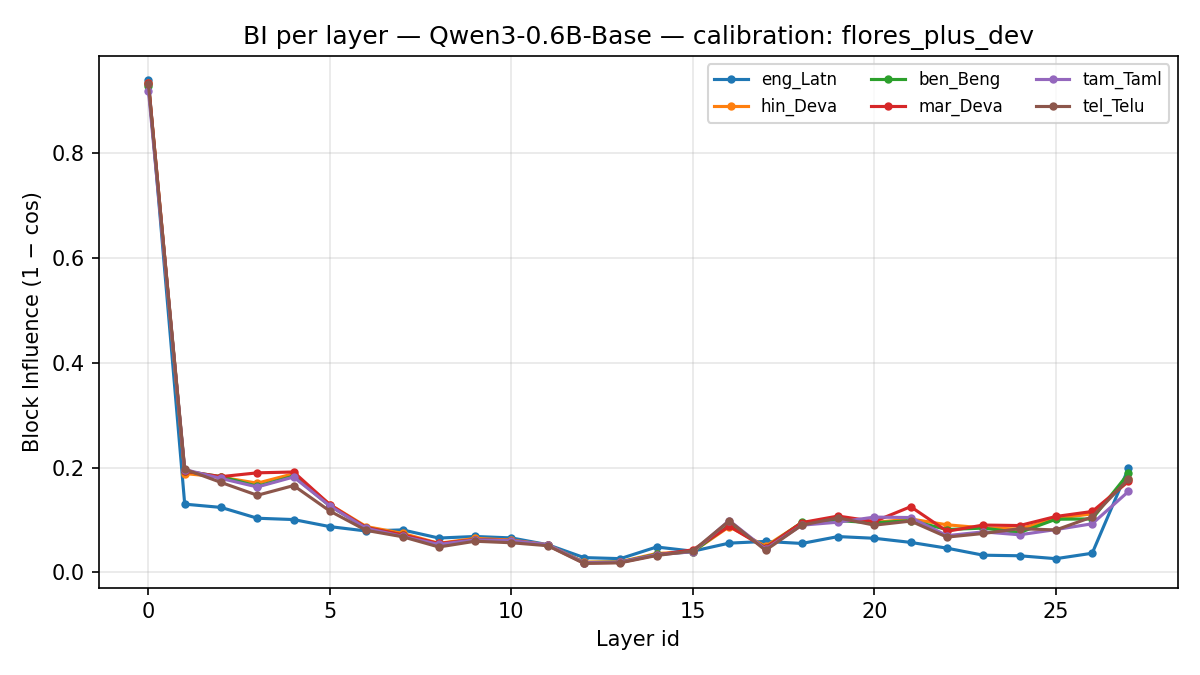

,layer,eng_Latn,hin_Deva,ben_Beng,mar_Deva,tam_Taml,tel_Telu
0,0,0.9397,0.9348,0.9288,0.9344,0.9194,0.9318
1,1,0.1302,0.1887,0.1933,0.1931,0.1962,0.1970
2,2,0.1239,0.1817,0.1827,0.1827,0.1792,0.1717
3,3,0.1033,0.1702,0.1643,0.1900,0.1630,0.1471
4,4,0.1008,0.1883,0.1836,0.1916,0.1820,0.1657
5,5,0.0873,0.1294,0.1268,0.1290,0.1267,0.1169
6,6,0.0789,0.0874,0.0853,0.0855,0.0840,0.0801
7,7,0.0810,0.0744,0.0712,0.0716,0.0688,0.0679
8,8,0.0655,0.0553,0.0528,0.0551,0.0532,0.0484
9,9,0.0684,0.0649,0.0625,0.0624,0.0620,0.0594


In [14]:
import pandas as pd
from IPython.display import Image, display
display(Image("figures/bi_Qwen3-0.6B-Base__flores_plus_dev.png"))
pd.read_csv("bi_scores/Qwen3-0.6B-Base__flores_plus_dev__bi_table.csv").round(4)

## Step 10 — The other two models: Qwen2.5-0.5B and BLOOM-560M
Same pipeline. BLOOM-560M was trained with Indic languages and tokenizes them far more efficiently than Qwen,
so it serves as a check on whether the differences come from the language or from tokenization.

In [16]:
!python run_bi.py --models Qwen/Qwen2.5-0.5B bigscience/bloom-560m --dtype float32 --selftest --overwrite


=== Qwen/Qwen2.5-0.5B  (cuda, float32) ===
Loading weights: 100% 290/290 [00:03<00:00, 75.26it/s]
  loaded in 18s: qwen2, 24 layers, hidden 896, vocab 151936
padding invariance: OK
  [eng_Latn] 997 sents, 26.3 tok/sent, pad 33.4%, 15s -> Qwen2.5-0.5B__flores_plus_dev__n997__eng_Latn.json
  [hin_Deva] 997 sents, 117.1 tok/sent, pad 33.9%, 62s -> Qwen2.5-0.5B__flores_plus_dev__n997__hin_Deva.json
  [ben_Beng] 997 sents, 133.1 tok/sent, pad 33.0%, 69s -> Qwen2.5-0.5B__flores_plus_dev__n997__ben_Beng.json
  [mar_Deva] 997 sents, 121.1 tok/sent, pad 32.3%, 63s -> Qwen2.5-0.5B__flores_plus_dev__n997__mar_Deva.json
  [tam_Taml] 997 sents, 160.6 tok/sent, pad 32.7%, 82s -> Qwen2.5-0.5B__flores_plus_dev__n997__tam_Taml.json
  [tel_Telu] 997 sents, 185.7 tok/sent, pad 34.5%, 96s -> Qwen2.5-0.5B__flores_plus_dev__n997__tel_Telu.json

  BI table -> bi_scores/Qwen2.5-0.5B__flores_plus_dev__bi_table.csv

  lang        tokens   pad%  rho vs eng  bottom-25% layers (would be removed)
  eng_Latn     26